In [83]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import matthews_corrcoef, accuracy_score

import torch as T
import torch.nn as nn

import sys
import logging
import argparse
import numpy as np
import pandas as pd
from typing import Any, Optional, List, Tuple
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
import os
import joblib
import csv
from pathlib import Path

# Machine Learning Modules
from sklearn.ensemble import RandomForestRegressor
from collections import defaultdict, Counter
from scipy.stats import pearsonr
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    r2_score,
    mean_squared_error)

In [84]:
random_state = 42
test_percentage = 0.20
np.random.seed(42)

In [ ]:
# --- Configuration: data-prep + model hyperparameters ----------------------
# These values are the result of an earlier hyperopt run on the canonical
# pipeline (see ML_models/ML_NN/hyperopt.py); we use them as fixed
# hyperparameters here so the tutorial runs end-to-end without a Spark cluster.

# ---------- data-prep ----------
KEEP_LAST_PERCENT = 60       # fraction of frames retained per sequence
NAVG              = 60       # rows averaged per chunk (per sequence)

# ---------- model architecture ----------
HIDDEN_LAYERS        = 3
HIDDEN_SIZE          = 8
DROPOUT_INPUT_OUTPUT = 0.13
DROPOUT_HIDDEN       = 0.33

# ---------- optimiser / training ----------
LEARNING_RATE = 0.005
WEIGHT_DECAY  = 7.69e-7
MAX_EPOCHS    = 5000
PATIENCE      = 50           # early-stopping patience (epochs)

# ---------- cross-validation ----------
KFOLD       = 5              # k folds per repeat
NUM_REPEATS = 3              # repeated K-fold splits

device = T.device("cuda" if T.cuda.is_available() else "cpu")
device


In [87]:
# torch_prep_kfold.py
# 
###########################################################################
# 1) INITIAL SPLIT
###########################################################################
id_col = 'sequence'
label_col = 'binding_type'
df1 = pd.read_csv('exp_data_all.csv')
ref_data = df1[[id_col, label_col]].copy()

print(ref_data)

## experimental training
usecols = ['sequence','VDWAALS','EEL','EGB','ESURF','HB Energy','Hydrophobic Energy','Pi-Pi Energy','Delta_Entropy']

df2 = pd.read_csv('rawdat.csv', usecols=usecols)
feature_data = df2.copy()

print(feature_data)

                                 sequence  binding_type
0    GAGGAAGCAGCCCTCGCCCCTGTCGGTGGAAAGAAG             0
1    GCAGCCGAGGCGGAGAGAGAGAGAGGACAGCTTACG             0
2    ATCTGATCAAAACAACGAATTCCAAAACAAAGTAAT             0
3    CCAATATTCCTTTGTGAGACCCTCCACAAATGCTAA             0
4    GAGGACGCGAACCGGCACGCTGCGCCTTTAAGGAGT             0
..                                    ...           ...
163  ACATAGGGACGGGGCCATGCGGTGGGCGGGTGGAAC             2
164  GAAAACCAGCGAGACCGCATGGTCTCACTTATAAGT             2
165  CGCGGAGACCCGAAGCACGTGGTATCCATACTAGTT             2
166  GCCCCCGACCCCGCGCACGCGGCCCCGCCCCGCGCG             2
167  ATTAGCCAAACTAAACACGTGTATTGATTTTAGATG             2

[168 rows x 2 columns]
                                    sequence  VDWAALS       EEL       EGB  \
0       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -252.110 -1886.830  1841.253   
1       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -238.510 -1881.424  1835.847   
2       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -246.721 -1895.687  1851.589

In [88]:
df_merged = pd.merge(feature_data, ref_data, on=id_col, how="inner")
print(df_merged.head(), df_merged.shape)

                               sequence  VDWAALS       EEL       EGB   ESURF  \
0  GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -252.110 -1886.830  1841.253 -36.482   
1  GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -238.510 -1881.424  1835.847 -36.023   
2  GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -246.721 -1895.687  1851.589 -35.802   
3  GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -235.671 -1857.573  1814.002 -34.799   
4  GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC -230.214 -1897.268  1847.934 -34.391   

   HB Energy  Hydrophobic Energy  Pi-Pi Energy  Delta_Entropy  binding_type  
0  -1.940432         -165.447020 -1.655191e-03     -26.046553             2  
1  -2.003962         -155.422935 -4.708262e-02     -24.150637             2  
2  -2.269901         -142.386371 -5.901517e-29     -24.329875             2  
3  -2.838678         -147.918585 -3.236084e-07     -23.615145             2  
4  -2.810414         -151.012478 -1.784784e-05     -23.698348             2   (272160, 10)


In [89]:
df_merged = df_merged.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


### Deriving a binary label: `binding_binary`

The reference table `exp_data_all.csv` already ships with a binary column called **`improving`**, computed in `scripts/process_gcPBM.ipynb` as

```python
exp['improving'] = exp['bind_avg'].apply(lambda x: 0 if x >= 7.7 else 1)
```

i.e. `improving = 0` for **binders** (`Log Intensity ≥ 7.7`) and `improving = 1` for **non-binders**. The name reflects the lab's mutational-engineering framing &mdash; "this sequence still has room to improve" = currently a non-binder &mdash; but it's the *opposite* of the conventional ML labeling where "positive class = the thing we want to detect."

For pedagogical clarity, this tutorial instead derives `binding_binary` from the three-class `binding_type` column:

* `binding_binary = 0` &rarr; non-binder (`binding_type == 0`, i.e. `Log Intensity ≤ 7.7`)
* `binding_binary = 1` &rarr; binder (`binding_type ∈ {1, 2}`, i.e. medium or strong binding)

So `binding_binary ≡ 1 - improving` (modulo the threshold-boundary edge case).

**Effect on metrics:** Accuracy and MCC are **mathematically invariant under joint label flipping** &mdash; flipping `0 ↔ 1` on both `y_true` and `y_pred` leaves both numbers unchanged. Since the canonical `run_model.py` only reports ACC and MCC for `bin`, this tutorial's headline numbers will match the paper exactly. The confusion-matrix cell *positions* swap (the "true binder, predicted binder" cell ends up in a different corner), but the counts and the story they tell are equivalent. F1 would differ &mdash; this tutorial doesn't compute it, but `process_results.ipynb` does.


In [90]:
df_merged["binding_binary"] = df_merged["binding_type"].apply(lambda x: 0 if x==0 else 1)
label_col = 'binding_binary'
df_merged = df_merged.drop(columns=["binding_type"])


In [91]:
from sklearn.model_selection import StratifiedGroupKFold
y_for_split = df_merged[label_col]
groups = df_merged[id_col]
gkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=random_state)
train_idx, test_idx = next(gkf.split(df_merged, y_for_split, groups=groups))
df_train = df_merged.iloc[train_idx].copy()
df_test  = df_merged.iloc[test_idx].copy()

In [92]:
print(df_train.columns)

Index(['sequence', 'VDWAALS', 'EEL', 'EGB', 'ESURF', 'HB Energy',
       'Hydrophobic Energy', 'Pi-Pi Energy', 'Delta_Entropy',
       'binding_binary'],
      dtype='object')


In [93]:
print(df_train)

                                    sequence  VDWAALS       EEL       EGB  \
0       CGGCTTTTTCTTGAACACGTGGAATATACTAGCGCT -207.264 -1958.570  1908.590   
1       TCCTAAACAGGAAGCCATGAGGTGAGCAGAGACACT -229.177 -1917.175  1870.986   
2       TTAGAAAAATAGTTTAAAATCTAGAGTTAATTAACC -197.506 -1830.441  1787.958   
3       CCAGCTCTCCACCGCCGCGTGCGCCTGCAGACGCTC -207.553 -1891.794  1845.707   
4       CCCCCAGCGCTCCGGCACGCGCCGGGAGACCTCCGG -201.484 -1923.635  1874.505   
...                                      ...      ...       ...       ...   
272155  TCTCCCCTTCCTCTCCGCGTGGCGGGCGCGGGTGCG -212.840 -1935.569  1883.328   
272156  TGTGGAGCAAGGGAGACAGAAGCTCATTGGCTAGAG -196.231 -1914.625  1866.175   
272157  AGAGGTAGGGTTAGGCGCGTGCCGCGAGAACAGAGT -186.779 -1891.556  1842.579   
272158  CCAGCCTGGACCGCCCCTGTGGGCTCCACTCCCCTC -199.291 -1903.864  1856.077   
272159  CTCAGGGCAGTTGGGCACGTGGGGTCCGGCTGGTTG -230.435 -1981.724  1926.780   

         ESURF  HB Energy  Hydrophobic Energy  Pi-Pi Energy  Delta_Entropy 

In [94]:
# save

train_file = f"bin_trn_final.csv"
test_file  = f"bin_tst_preprocess.csv"
df_train.to_csv(train_file, index=False)
df_test.to_csv(test_file, index=False)

In [95]:
## helper functions

def keep_last_n_percent(df: pd.DataFrame, seq_col: str, keep_percent: float) -> pd.DataFrame:
    """
    Retain only the last keep_percent fraction of rows in each sequence group.
    If 'run' column exists, sort by it first.
    """
    if keep_percent <= 0 or keep_percent >= 100:
        return df
    if "run" in df.columns:
        df_sorted = df.sort_values([seq_col, "run"], kind="mergesort")
    else:
        df_sorted = df.copy()
    group_sizes = df_sorted.groupby(seq_col)[seq_col].transform("size")
    cumcount = df_sorted.groupby(seq_col).cumcount()
    n_keep = (group_sizes * (keep_percent / 100.0)).astype(int)
    n_keep = n_keep.mask(n_keep < 1, 1)  # ensure at least 1 row if fraction>0
    mask = cumcount >= (group_sizes - n_keep)
    return df_sorted[mask].reset_index(drop=True)

def average_features_for_sequence(
    df: pd.DataFrame,
    navg: int,
    id_col: str,
    label_col: str,
    random_state: int
) -> pd.DataFrame:
    """
    Shuffle the sequence's rows, chunk into size navg, and average numeric features.
    Label = label from the first row of each chunk.
    """
    results = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in [id_col, label_col]]
    df_shuffled = df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    n_chunks = len(df_shuffled) // navg
    if n_chunks < 1:
        return pd.DataFrame(columns=df.columns)
    for i in range(n_chunks):
        chunk = df_shuffled.iloc[i * navg : (i + 1) * navg]
        row_dict = {col: chunk[col].mean() for col in feature_cols}
        row_dict[label_col] = chunk[label_col].iloc[0]
        row_dict[id_col] = chunk[id_col].iloc[0]
        results.append(row_dict)
    df_out = pd.DataFrame(results)
    col_order = [id_col] + sorted([c for c in df_out.columns if c != id_col])
    return df_out[col_order]

def average_features_for_mutants(
    df: pd.DataFrame,
    navg: int,
    id_col: str,
    label_col: str,
    random_state: int
) -> pd.DataFrame:
    """
    Apply the above averaging function per sequence group, then concat.
    """
    all_chunks = []
    for seq, group in df.groupby(id_col):
        chunk_df = average_features_for_sequence(group, navg, id_col, label_col, random_state)
        all_chunks.append(chunk_df)
    if not all_chunks:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(all_chunks, ignore_index=True)

def compute_mean_std(
    df: pd.DataFrame,
    model_type: str,
    id_col: str,
    label_col: str
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute mean/std for numeric columns (excluding ID and label).
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if id_col in numeric_cols:
        numeric_cols.remove(id_col)
    if label_col in numeric_cols:
        numeric_cols.remove(label_col)
    means = [(c, df[c].mean()) for c in numeric_cols]
    stds  = [(c, df[c].std())  for c in numeric_cols]
    return (
        pd.DataFrame(means, columns=["colname", "mean"]),
        pd.DataFrame(stds, columns=["colname", "std"])
    )

def save_mean_std(mean_df: pd.DataFrame, std_df: pd.DataFrame, filename: str) -> None:
    merged = pd.merge(mean_df, std_df, on="colname")
    merged.to_csv(filename, index=False)

def load_mean_std(filename: str) -> pd.DataFrame:
    df_stats = pd.read_csv(filename)
    needed_cols = {"colname", "mean", "std"}
    return df_stats

def apply_standardization(
    df: pd.DataFrame,
    stats_df: pd.DataFrame,
    model_type: str,
    id_col: str,
    label_col: str
) -> pd.DataFrame:
    df_std = df.copy()
    means = dict(zip(stats_df["colname"], stats_df["mean"]))
    stds  = dict(zip(stats_df["colname"], stats_df["std"]))
    for col in df_std.columns:
        if col in [id_col, label_col]:
            continue
        if col in means and col in stds:
            mu  = means[col]
            sigma = stds[col]
            if sigma == 0 or np.isnan(sigma):
                df_std[col] = df_std[col] - mu
            else:
                df_std[col] = (df_std[col] - mu) / sigma
    return df_std


### A note on `keep_last_n_percent`

The helper above is *intended* to keep the **last X% of frames per sequence**, i.e. the equilibrated tail of each MD trajectory, by sorting each sequence's rows by the `run` column first.

In this pipeline `run` was dropped when we set `usecols` while reading `rawdat.csv`, so the `if "run" in df.columns:` branch never fires here. The canonical pipeline (`ML_models/ML_NN/torch_prep_kfold.py`) drops `run` at the same point too, so its behavior is identical.

What `keep_last_n_percent` therefore *actually* does in both this tutorial and the canonical code is: keep a deterministic X% per sequence in whatever order the rows currently appear &mdash; which, after the upstream shuffle, is effectively a random subsample. The hyperparameter `keep_last_percent` is still meaningful (it controls the fraction of frames retained), but it does **not** select the equilibrated tail.

We keep the tutorial bug-for-bug consistent with the canonical scripts here so that the figures in the paper remain reproducible. This is recorded as a known issue in `CLAUDE.md` &rarr; *Open questions / risks*.


In [96]:
df_train = keep_last_n_percent(df_train, id_col, KEEP_LAST_PERCENT)


In [97]:
print(df_train.shape)

(139968, 10)


In [98]:
# Average numeric features in chunks of size --navg
df_train_avg = average_features_for_mutants(
    df_train,
    navg=NAVG,
    id_col=id_col,
    label_col=label_col,
    random_state=random_state)

In [99]:
# Compute and save mean/std
mean_df, std_df = compute_mean_std(df_train_avg, 'bin', id_col, label_col)
stats_file = f"bin_train_stats.csv"
save_mean_std(mean_df, std_df, stats_file)


In [100]:
# Apply standardization
df_train_std = apply_standardization(
    df_train_avg,
    load_mean_std(stats_file),
    'bin',
    id_col,
    label_col
)

In [101]:
# Shuffle once more
df_train_std = df_train_std.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


In [102]:
# Repeated K-fold

from sklearn.model_selection import StratifiedGroupKFold
y_for_split = df_train_std[label_col]
groups      = df_train_std[id_col]



In [103]:

for repeat_idx in range(NUM_REPEATS):
    # (Optional) offset seed if you want different splits each repeat
    repeat_seed = random_state + 100 * repeat_idx

    kf = StratifiedGroupKFold(n_splits=KFOLD, shuffle=True, random_state=repeat_seed)
    split_iter = kf.split(df_train_std, y_for_split, groups)

    fold_counter = 0
    for trn_idx, val_idx in split_iter:
        df_fold_trn = df_train_std.iloc[trn_idx].copy()
        df_fold_val = df_train_std.iloc[val_idx].copy()

        col_order = [id_col] + [c for c in df_fold_trn.columns if c != id_col]
        df_fold_trn = df_fold_trn[col_order]
        df_fold_val = df_fold_val[col_order]

        fold_train_csv = f"bin_trn_{repeat_idx}_{fold_counter}.csv"
        fold_val_csv   = f"bin_val_{repeat_idx}_{fold_counter}.csv"
        df_fold_trn.to_csv(fold_train_csv, index=False)
        df_fold_val.to_csv(fold_val_csv, index=False)

        fold_counter += 1


### Now for Test set

In [104]:
print(df_test.shape)
# 1 sequence + 8 features + 1 label

(38880, 10)


In [105]:
df_test = keep_last_n_percent(df_test, id_col, KEEP_LAST_PERCENT)
df_test_avg = average_features_for_mutants(
    df_test,
    navg=NAVG,
    id_col=id_col,
    label_col=label_col,
    random_state=random_state)

In [106]:
df_test_std = apply_standardization(
    df_test_avg,
    load_mean_std(stats_file),
    'bin',
    id_col,
    label_col
)

In [107]:
#shuffle
df_test_std = df_test_std.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

final_test_csv = f"bin_tst_final.csv"
df_test_std.to_csv(final_test_csv, index=False)

### Process train

In [110]:
'''
Modes:
------
1) mode=0 (training):
   - For each fraction in --scramble_fractions,
     - For each repeat_idx in [0..num_repeats-1] and fold_idx in [0..kfold-1]:
         * Load the CSV files:
             {prefix}_{model_type}_scrFRAC_trn_{repeat_idx}_{fold_idx}.csv
             {prefix}_{model_type}_scrFRAC_val_{repeat_idx}_{fold_idx}.csv
         * Instantiate the MLP with arguments:
             --hidden_size, --hidden_layers, --dropout_input_output, --dropout_hidden
         * Train the network (with optional early stopping);
           save best model checkpoint to:
             nn_fold_{repeat_idx}_{fold_idx}_{model_type}_scrFRAC.pth
         * Evaluate on the validation split → collect metrics & row-level predictions.
'''

'\nModes:\n------\n1) mode=0 (training):\n   - For each fraction in --scramble_fractions,\n     - For each repeat_idx in [0..num_repeats-1] and fold_idx in [0..kfold-1]:\n         * Load the CSV files:\n             {prefix}_{model_type}_scrFRAC_trn_{repeat_idx}_{fold_idx}.csv\n             {prefix}_{model_type}_scrFRAC_val_{repeat_idx}_{fold_idx}.csv\n         * Instantiate the MLP with arguments:\n             --hidden_size, --hidden_layers, --dropout_input_output, --dropout_hidden\n         * Train the network (with optional early stopping);\n           save best model checkpoint to:\n             nn_fold_{repeat_idx}_{fold_idx}_{model_type}_scrFRAC.pth\n         * Evaluate on the validation split → collect metrics & row-level predictions.\n'

In [111]:
###############################################################################
# Utility Functions
###############################################################################
def fmt_float(x: float) -> str:
    """
    Format a float with 4 digits after the decimal.
    If `x` is NaN or not a float → return the string 'NaN'.
    """
    return f"{x:.4f}" if isinstance(x, float) and not np.isnan(x) else "NaN"


def majority_vote(values: List[int]) -> int:
    """
    Return the most common integer in *values*.
    Ties are broken by `pandas.Series.mode()`, which returns the
    first encountered mode.
    """
    return int(pd.Series(values).mode()[0])

In [112]:
###############################################################################
# Data Loading
###############################################################################
def load_csv_data(csv_file: str, id_col, label_col) -> Tuple[T.Tensor, T.Tensor, List[Any]]:
    """
    Read a CSV file and convert to PyTorch tensors.
    *   ID   column → kept as Python list for aggregation.
    * target column → 1-D float32 tensor (with extra dim so shape = [N,1]).
    * feature cols → float32 tensor  (shape = [N, #features])
    """
    if not os.path.isfile(csv_file):
        raise FileNotFoundError(f"Data file not found: {csv_file}")

    df = pd.read_csv(csv_file, header=0)
    id_col, label_col = id_col, label_col

    if id_col not in df.columns or label_col not in df.columns:
        raise ValueError(
            f"CSV {csv_file} must contain '{id_col}' and '{label_col}' columns."
        )

    # treat every other column as numeric feature
    feature_cols = [c for c in df.columns if c not in [id_col, label_col]]

    ids      = df[id_col].tolist()
    features = T.tensor(df[feature_cols].values.astype(np.float32))
    targets  = T.tensor(df[label_col].values.astype(np.float32)).unsqueeze(1)
    return features, targets, ids

In [113]:
###############################################################################
# Neural Network Definition
###############################################################################
class Net(T.nn.Module):
    """
    Simple fully-connected network:
    [input] → ReLU → (dropout) → hidden × (L-1) → ReLU → (dropout) → out
    Output layer:
       * regression / binary cls → 1 neuron
       * multi-class             → `num_classes` neurons (logits)
    """
    def __init__(self, input_dim: int, hidden_size, num_classes, hidden_layers, dropout_input_output, dropout_hidden, model_type = 'bin',):
        super().__init__()

        # ---------------- network architecture --------------------------- #
        # out_dim = args.num_classes if args.model_type == "mclass" else 1
        out_dim = 1

        layers = []
        # first layer
        layers.append(T.nn.Linear(input_dim, hidden_size))
        # additional hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(T.nn.Linear(hidden_size, hidden_size))
        # final output
        layers.append(T.nn.Linear(hidden_size, out_dim))
        self.layers = T.nn.ModuleList(layers)

        # activation / dropout
        self.act          = T.nn.ReLU()
        self.dropout_io   = T.nn.Dropout(dropout_input_output)
        self.dropout_hid  = T.nn.Dropout(dropout_hidden)

        self._init_weights()   # Xavier init
        # self.args = args

    def _init_weights(self):
        """Xavier-uniform for weights, zeros for biases."""
        for layer in self.layers:
            T.nn.init.xavier_uniform_(layer.weight)
            T.nn.init.zeros_(layer.bias)

    def forward(self, x: T.Tensor) -> T.Tensor:
        """
        Forward pass with dropout after first & hidden layers.
        """
        x = self.dropout_io(self.act(self.layers[0](x)))
        for layer in self.layers[1:-1]:
            x = self.dropout_hid(self.act(layer(x)))
        return self.layers[-1](x)   # logits / regression value


In [114]:
###############################################################################
# Loss Function 
###############################################################################
def get_loss_function(model_type ='bin'):
    """Return the appropriate criterion given task type."""
    if model_type == "reg":
        return T.nn.MSELoss()
    elif model_type == "bin":
        return T.nn.BCEWithLogitsLoss()
    elif model_type == "mclass":
        return T.nn.CrossEntropyLoss()
    else:
        raise ValueError(f"Unknown model_type '{args.model_type}'")

In [115]:
###############################################################################
# Early-Stopping Helper
###############################################################################
class EarlyStopper:
    """
    Monitor a validation metric (`min` or `max`) and stop training if it
    hasn't improved for `patience` epochs. Stores the best model weights.
    """
    def __init__(self, patience=20, mode="min"):
        self.patience   = patience
        self.mode       = mode
        self.best_value = None
        self.counter    = 0
        self.should_stop = False
        self.best_model_state = None

    def check(self, current_value, model_state_dict):
        """
        Update internal state; set `should_stop` if patience exceeded.
        """
        if self.best_value is None:
            # first observation
            self.best_value = current_value
            self.best_model_state = model_state_dict
            return

        improved = (
            current_value < self.best_value if self.mode == "min"
            else current_value > self.best_value
        )

        if improved:
            self.best_value = current_value
            self.best_model_state = model_state_dict
            self.counter = 0           # reset patience
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


In [116]:
def train_model(
    net: Net,
    trn_feat: T.Tensor,
    trn_tgt: T.Tensor,
    val_feat: T.Tensor,
    val_tgt: T.Tensor,
    lrn_rate: float,
    wt_decay: float,
    max_epochs: int,
    use_early_stopping: bool = True,
    patience: int = 20,
    model_type: str = 'bin'
):
    """
    minibatch-free training loop (full-batch gradient descent).
    Early stopping optional. Metrics printed every 10 % of epochs.
    """

    # loss
    criterion = get_loss_function(model_type='bin')

    # optimizer
    optimizer = T.optim.Adam(
        net.parameters(),
        lr=lrn_rate,
        weight_decay=wt_decay
    )

    # early stopping
    early_stopper = (
        EarlyStopper(patience=patience, mode="min")
        if use_early_stopping else None
    )

    log_every = max(1, max_epochs // 10)

    for ep in range(max_epochs):
        optimizer.zero_grad()

        preds = net(trn_feat)
        loss = criterion(preds, trn_tgt)
        loss.backward()
        optimizer.step()

        # periodic logging
        if (ep + 1) % log_every == 0:
            logging.info(
                f"[Epoch {ep+1}/{max_epochs}] train-loss={loss.item():.4f}"
            )

        # ---------------- early stopping ---------------- #
        if early_stopper:
            net.eval()
            with T.no_grad():
                val_preds = net(val_feat)
                val_loss = criterion(val_preds, val_tgt).item()
            net.train()

            early_stopper.check(val_loss, net.state_dict())
            if early_stopper.should_stop:
                logging.info(
                    f"Early stopping at epoch {ep+1} "
                    f"(best val-loss={early_stopper.best_value:.4f})"
                )
                net.load_state_dict(early_stopper.best_model_state)
                break


In [117]:
###############################################################################
# CSV Helper
###############################################################################
def save_predictions(predictions, filename: str):
    """
    Write a CSV with three columns: *Label*, *Predicted*, *True*.
    `predictions` is an iterable of tuples (label, pred, tgt).
    """
    with open(filename, "w", newline="") as f:
        wr = csv.writer(f)
        wr.writerow(["Label", "Predicted", "True"])
        wr.writerows(predictions)

In [118]:
###############################################################################
# Evaluation / Prediction
###############################################################################
def evaluate_model(net: Net,
                   features: T.Tensor,
                   targets: T.Tensor,
                   ids: List[Any],
                   ):
    """
    Forward-prop through the network and compute metrics.  
    Multiple rows may share the same ID (e.g., snapshots of same complex).
    Rows → aggregated to per-ID predictions:

    * Regression  → average of predictions.
    * Classification → majority vote (or summed logits for mclass).
    """
    net.eval()
    with T.no_grad():
        out = net(features)

    logits = out.detach().cpu().numpy().flatten()  # raw scores
    tgt_np = targets.detach().cpu().numpy().flatten()
    row_preds = (logits > 0.0).astype(int)

    aggregator = defaultdict(lambda: {"preds": [], "tgt": []})
    row_level_data = []

    for i, uid in enumerate(ids):
        aggregator[uid]["preds"].append(int(row_preds[i]))
        aggregator[uid]["tgt"].append(int(tgt_np[i]))
        row_level_data.append((uid, int(row_preds[i]), int(tgt_np[i])))

    agg_preds = [majority_vote(d["preds"]) for d in aggregator.values()]
    agg_tgts  = [majority_vote(d["tgt"])  for d in aggregator.values()]

    mcc, acc = float('nan'), float('nan')
    if len(set(agg_tgts)) > 1:
        mcc = matthews_corrcoef(agg_tgts, agg_preds)
        acc = accuracy_score(agg_tgts,  agg_preds)

    return (np.nan, np.nan, np.nan, mcc, acc, row_level_data)


In [119]:
## TRAINING

model_dir= "Model/" # Directory for saving/loading models.
data_dir = "."

all_metrics = []
all_predictions = []

# ------------------- iterate repeats / folds -------------------- #
for repeat_idx in range(NUM_REPEATS):
    for fold_idx in range(KFOLD):
        # -------- locate CSVs produced by external data-prep ------ #
        trn_file = os.path.join(
            data_dir,
            f"bin_trn_{repeat_idx}_{fold_idx}.csv"
        )
        val_file = os.path.join(
            data_dir,
            f"bin_val_{repeat_idx}_{fold_idx}.csv"
        )

        # ------------------- load data --------------------------- #
        X_trn, y_trn, ids_trn = load_csv_data(trn_file, id_col, label_col)
        X_val, y_val, ids_val = load_csv_data(val_file, id_col, label_col)

        # ------------------- build & train ----------------------- #
        net = Net(
        input_dim=X_trn.shape[1],
        model_type="bin",
        num_classes=1,      # ignored for binary
        hidden_size=HIDDEN_SIZE,
        hidden_layers=HIDDEN_LAYERS,
        dropout_input_output=DROPOUT_INPUT_OUTPUT,
        dropout_hidden=DROPOUT_HIDDEN
        )

        train_model(net, X_trn, y_trn, X_val, y_val,
                    lrn_rate=LEARNING_RATE,
                    wt_decay=WEIGHT_DECAY,
                    max_epochs=MAX_EPOCHS,
                    use_early_stopping=True,
                    patience=PATIENCE)

        # save model checkpoint
        model_path = os.path.join(
            model_dir,
            f"nn_fold_{repeat_idx}_{fold_idx}_bin.pth"
        )
        T.save(net.state_dict(), model_path)

        # ------------------- validation metrics ------------------ #
        mse,r2,pear,mcc,acc,fold_preds = evaluate_model(
            net, X_val, y_val, ids_val
        )
        all_metrics.append(
            {"MSE": mse, "R2": r2, "Pear": pear, "MCC": mcc, "Accuracy": acc}
        )
        all_predictions.extend(fold_preds)

        # save per-fold prediction CSV
        fold_csv = (f"predictions_bin"
                    f"_rep{repeat_idx}_fold{fold_idx}.csv")
        save_predictions(fold_preds, fold_csv)

In [120]:
# ------------------ aggregate metrics across folds -------------- #
if all_metrics:
    avg_metrics = {}
    for key in all_metrics[0]:
        vals = [m[key] for m in all_metrics if not np.isnan(m[key])]
        avg_metrics[key] = float(np.mean(vals)) if vals else float('nan')

    for k,v in avg_metrics.items():
        logging.info(f"  {k} = {fmt_float(v)}")

    # write metrics CSV
    with open(f"final_metrics_bin_trn_.csv",
                "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["MSE","R2","Pear","MCC","Accuracy"])
        w.writeheader()
        w.writerow({k: fmt_float(v) for k,v in avg_metrics.items()})

In [122]:
# ------------------ aggregate predictions by ID ----------------- #
if all_predictions:
    aggregator = defaultdict(lambda: {"preds": [], "tgt": []})
    for uid, pred, tgt in all_predictions:
        aggregator[uid]["preds"].append(pred)
        aggregator[uid]["tgt"].append(tgt)

    labels, preds, tgts = [], [], []
    for uid, d in aggregator.items():
        labels.append(uid)
        preds.append(majority_vote(d["preds"]))
        tgts.append(majority_vote(d["tgt"]))

    pd.DataFrame({
        "Label": labels,
        "AvgPredicted": preds,
        "AvgTrue": tgts
    }).to_csv(f"predictions_bin_final_avg.csv",
                index=False)

In [123]:
### Evalaution mode

In [124]:
test_csv = os.path.join(
    data_dir,
    f"bin_tst_final.csv"
)

X_tst, y_tst, ids_tst = load_csv_data(test_csv, id_col, label_col)

predictions, metrics = [], []

for repeat_idx in range(NUM_REPEATS):
    for fold_idx in range(KFOLD):
        model_path = os.path.join(
            model_dir,
            f"nn_fold_{repeat_idx}_{fold_idx}_bin.pth"
        )


        net = Net(
        input_dim=X_trn.shape[1],
        model_type="bin",
        num_classes=1,      # ignored for binary
        hidden_size=HIDDEN_SIZE,
        hidden_layers=HIDDEN_LAYERS,
        dropout_input_output=DROPOUT_INPUT_OUTPUT,
        dropout_hidden=DROPOUT_HIDDEN
        )

        net.load_state_dict(T.load(model_path, map_location="cpu"))

        mse,r2,pear,mcc,acc,fold_preds = evaluate_model(
            net, X_tst, y_tst, ids_tst
        )
        predictions.extend(fold_preds)
        metrics.append(
            {"MSE": mse, "R2": r2, "Pear": pear, "MCC": mcc, "Accuracy": acc}
        )


# ----------- save row-level predictions ------------------------- #
save_predictions(
    predictions,
    f"predictions_test_bin.csv"
)

# ----------- aggregate & save test metrics ---------------------- #
if metrics:
    avg_metrics = {}
    for key in metrics[0]:
        vals = [m[key] for m in metrics if not np.isnan(m[key])]
        avg_metrics[key] = float(np.mean(vals)) if vals else float('nan')


    with open(f"final_metrics_bin_tst.csv",
                "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["MSE","R2","Pear","MCC","Accuracy"])
        w.writeheader()
        w.writerow({k: fmt_float(v) for k,v in avg_metrics.items()})


In [ ]:
# Aggregate the row-level test predictions into one prediction per sequence.
#
# `predictions_test_bin.csv` (written by the loop above) is the *concatenation*
# of every (rep, fold) checkpoint's prediction on every test row, so each
# sequence appears NUM_REPEATS * KFOLD = 15 times. To get a single ensemble
# prediction per sequence we majority-vote those 15 calls. This mirrors what
# the training side does to produce `predictions_bin_final_avg.csv`, and is
# what downstream confusion-matrix cells should consume — otherwise the CM
# is computed on 15x the actual number of test sequences.

df_test_rows = pd.read_csv("predictions_test_bin.csv")

agg_test = defaultdict(lambda: {"preds": [], "tgt": []})
for _, row in df_test_rows.iterrows():
    agg_test[row["Label"]]["preds"].append(int(row["Predicted"]))
    agg_test[row["Label"]]["tgt"].append(int(row["True"]))

labels, preds, tgts = [], [], []
for uid, d in agg_test.items():
    labels.append(uid)
    preds.append(majority_vote(d["preds"]))
    tgts.append(majority_vote(d["tgt"]))

pd.DataFrame({
    "Label": labels,
    "AvgPredicted": preds,
    "AvgTrue": tgts,
}).to_csv("predictions_test_bin_final_avg.csv", index=False)

print(f"Aggregated {len(df_test_rows)} row-level predictions "
      f"into {len(labels)} per-sequence predictions.")


In [125]:

pred_trn_df = pd.read_csv('predictions_bin_final_avg.csv')
print(pred_trn_df.head()) # Display the first few rows of the DataFrame

pred_tst_df = pd.read_csv('predictions_test_bin.csv')


                                  Label  AvgPredicted  AvgTrue
0  CAATGACTGCTGGGGCACGTGCCAGCCTCGGTAGAG             1        1
1  ATTAGCCAAACTAAACACGTGTATTGATTTTAGATG             1        1
2  AGCCGCTGCCGCCCCCACGTGGCAAATCTGGGGCTC             1        1
3  GGGCTCCCAGGGGCTGCTGCTGCCTTTCCGGTCTTG             0        0
4  CCGGGGCTTAAGTTCCATGCGTTGGATTCCTCGCTT             1        0


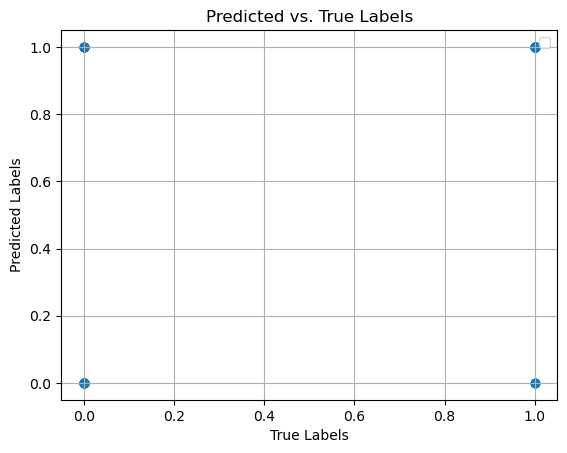

In [126]:
import matplotlib.pyplot as plt

plt.scatter(pred_trn_df['AvgTrue'], pred_trn_df['AvgPredicted'], alpha=0.6)

plt.title('Predicted vs. True Labels')
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')
plt.legend()
plt.grid(True)
plt.show()


In [127]:
'''
Scatterplots are not useful for binary classification, we need to make confusion matrices
'''

'\nScatterplots are not useful for binary classification, we need to make confusion matrices\n'

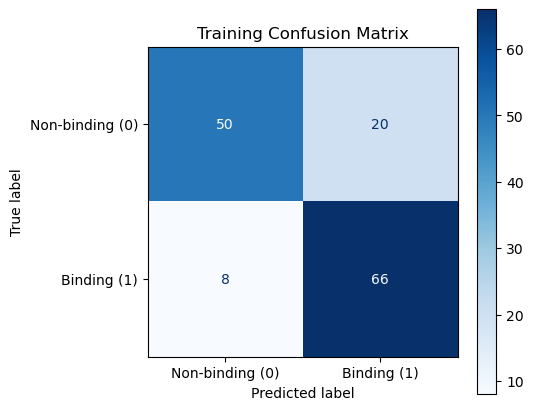

In [128]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the file
df_train = pd.read_csv("predictions_bin_final_avg.csv")

y_true = df_train["AvgTrue"].astype(int)
y_pred = df_train["AvgPredicted"].astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-binding (0)", "Binding (1)"]
)
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Training Confusion Matrix")
plt.show()


In [ ]:
# Read the per-sequence aggregated test predictions (one row per sequence,
# majority-voted across the rep x fold checkpoints).
df_test = pd.read_csv("predictions_test_bin_final_avg.csv")

y_true_test = df_test["AvgTrue"].astype(int)
y_pred_test = df_test["AvgPredicted"].astype(int)

cm_test = confusion_matrix(y_true_test, y_pred_test)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Non-binding (0)", "Binding (1)"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp_test.plot(ax=ax, cmap="Purples", values_format='d')
plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_row_percent(y_true, y_pred, title="Confusion Matrix"):
    """
    Plots confusion matrix where EACH ROW sums to 100%.
    (Shows conditional accuracy for each true class)
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_row_sum = cm.sum(axis=1, keepdims=True)
    cm_perc = cm / cm_row_sum * 100  # row-normalized percentages

    # Class 0 = Non-binding, class 1 = Binding (see the `binding_binary` cell above).
    # sklearn's confusion_matrix returns rows/cols in ascending class order, so
    # axis index 0 corresponds to "Non-binding" and 1 to "Binding".
    labels = ["Non-binding", "Binding"]

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_perc, cmap="Greens")

    # axis
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # annotate cells
    for i in range(2):
        for j in range(2):
            text = f"{cm[i,j]}\n({cm_perc[i,j]:.1f}%)"
            ax.text(j, i, text,
                    ha='center', va='center',
                    color='black' if cm_perc[i,j] > 50 else 'black',
                    fontsize=12)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


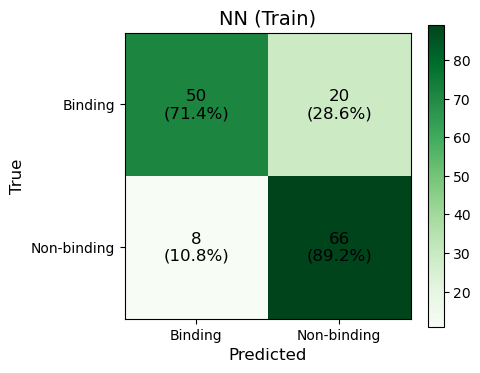

In [133]:
df_train = pd.read_csv("predictions_bin_final_avg.csv")
plot_confusion_matrix_row_percent(df_train["AvgTrue"], df_train["AvgPredicted"], 
                                  "NN (Train)")


In [ ]:
df_test = pd.read_csv("predictions_test_bin_final_avg.csv")
plot_confusion_matrix_row_percent(df_test["AvgTrue"], df_test["AvgPredicted"],
                                  "NN (Test)")
